# Practical Exercise 6
## Statistical analysis: Stationarity
### The goal of this practical exercise is to study the stationarity of random variables and learn to implement specific tests to determine, whether the process is stationary or not.

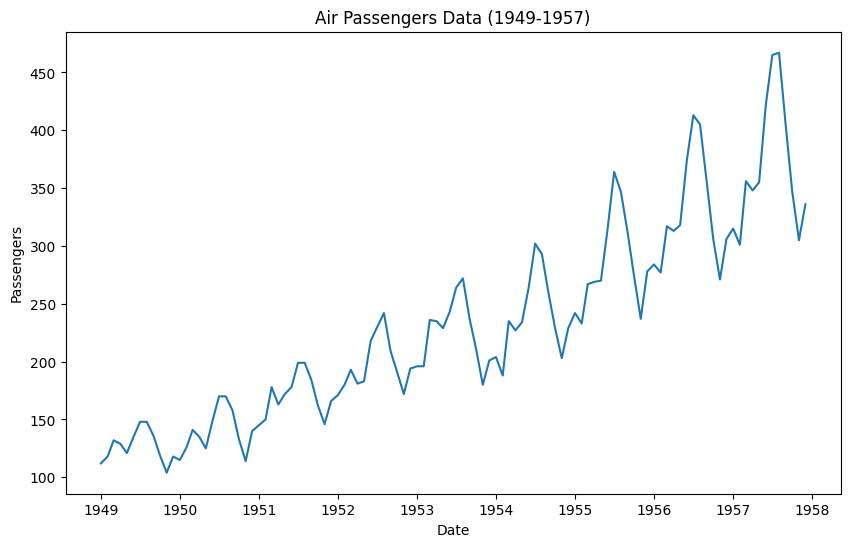

In [1]:
# Task One

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose

url = '/content/sample_data/AirPassengers.csv'
df = pd.read_csv(url, parse_dates=['Month'], index_col='Month')
df = df['1949-01-01':'1957-12-31']

plt.figure(figsize=(10,6))
plt.plot(df)
plt.title('Air Passengers Data (1949-1957)')
plt.xlabel('Date')
plt.ylabel('Passengers')
plt.show()

We can see the passenger numbers are going up steadily from 1949 to 1957. It's not just a straight line though; there are regular waves every year, probably for holidays, and the waves get bigger as time goes on.

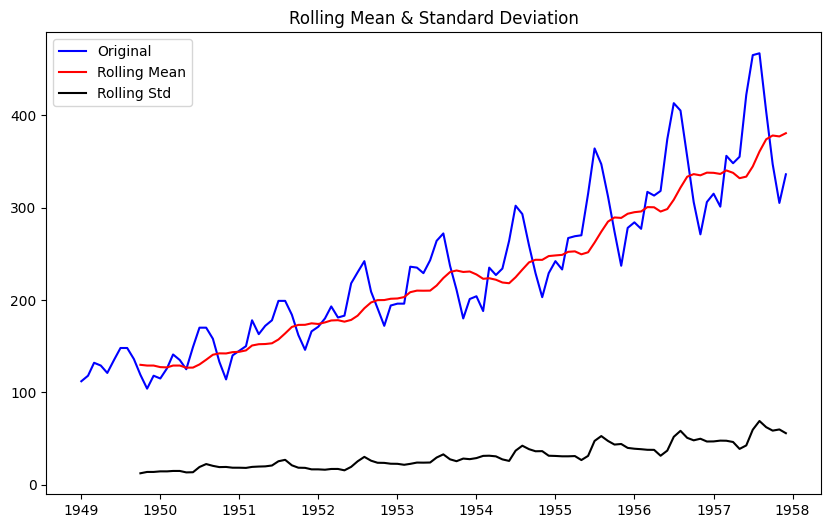

In [2]:
# Task Two

window_size = 10
rolmean = df.rolling(window=window_size).mean()
rolstd = df.rolling(window=window_size).std()

plt.figure(figsize=(10,6))
plt.plot(df, color='blue', label='Original')
plt.plot(rolmean, color='red', label='Rolling Mean')
plt.plot(rolstd, color='black', label='Rolling Std')
plt.legend(loc='best')
plt.title('Rolling Mean & Standard Deviation')
plt.show()

The rolling statistics confirm that the series isn't stable. The red rolling mean line is constantly climbing, so it confirmed what we saw earlier. Also, the standard deviation moves up a bit, so the volatility isn't constant. As the mean nor the variance is stable, the process is non-stationary.

In [7]:
# Task Three

print('Results of Dickey-Fuller Test:')
dftest = adfuller(df['#Passengers'], autolag='AIC')
dfoutput = pd.Series(dftest[0:4], index=['Test Statistic','p-value','#Lags Used','Number of Observations Used'])
for key,value in dftest[4].items():
    dfoutput['Critical Value (%s)'%key] = value
print(dfoutput)

Results of Dickey-Fuller Test:
Test Statistic                  1.002587
p-value                         0.994293
#Lags Used                     13.000000
Number of Observations Used    94.000000
Critical Value (1%)            -3.501912
Critical Value (5%)            -2.892815
Critical Value (10%)           -2.583454
dtype: float64


The ADF test results show that the time series is not stationary. The test statistic is 1.002587 and the p-value is high at roughly 0.99. We can conclude mathematically that the process has a time-dependent structure and thus is not stationary.

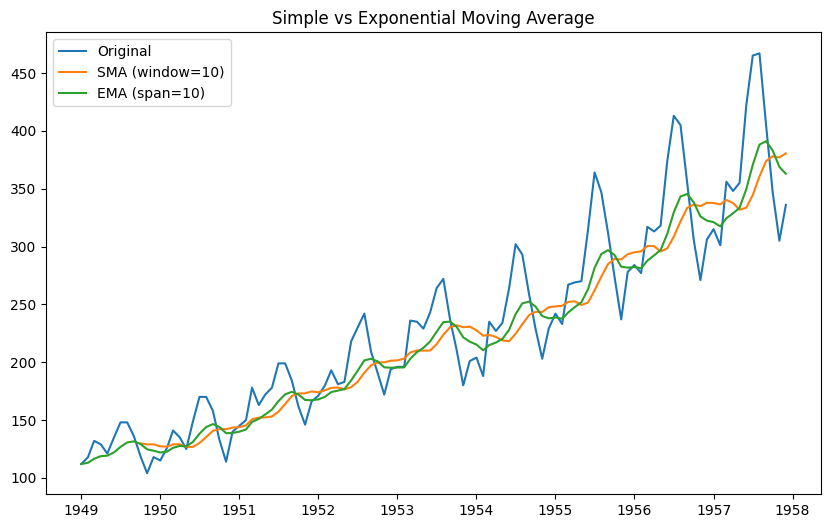

In [6]:
# Task Four

sma = df.rolling(window=10).mean()
ema = df.ewm(span=10, adjust=False).mean()

plt.figure(figsize=(10,6))
plt.plot(df, label='Original')
plt.plot(sma, label='SMA (window=10)')
plt.plot(ema, label='EMA (span=10)')
plt.legend()
plt.title('Simple vs Exponential Moving Average')
plt.show()

The plot shows a difference in how the two moving averages react. The Simple Moving Average (orange line) is a smoother curve but "lags" compare to the real data. Whereas, the Exponential Moving Average (green line) is more in accordance with the original blue curve and adjusts more quickly to changes. This is because the EMA places more weight on the most recent data points, making it more sensitive to the immediate volatility compared to the SMA.

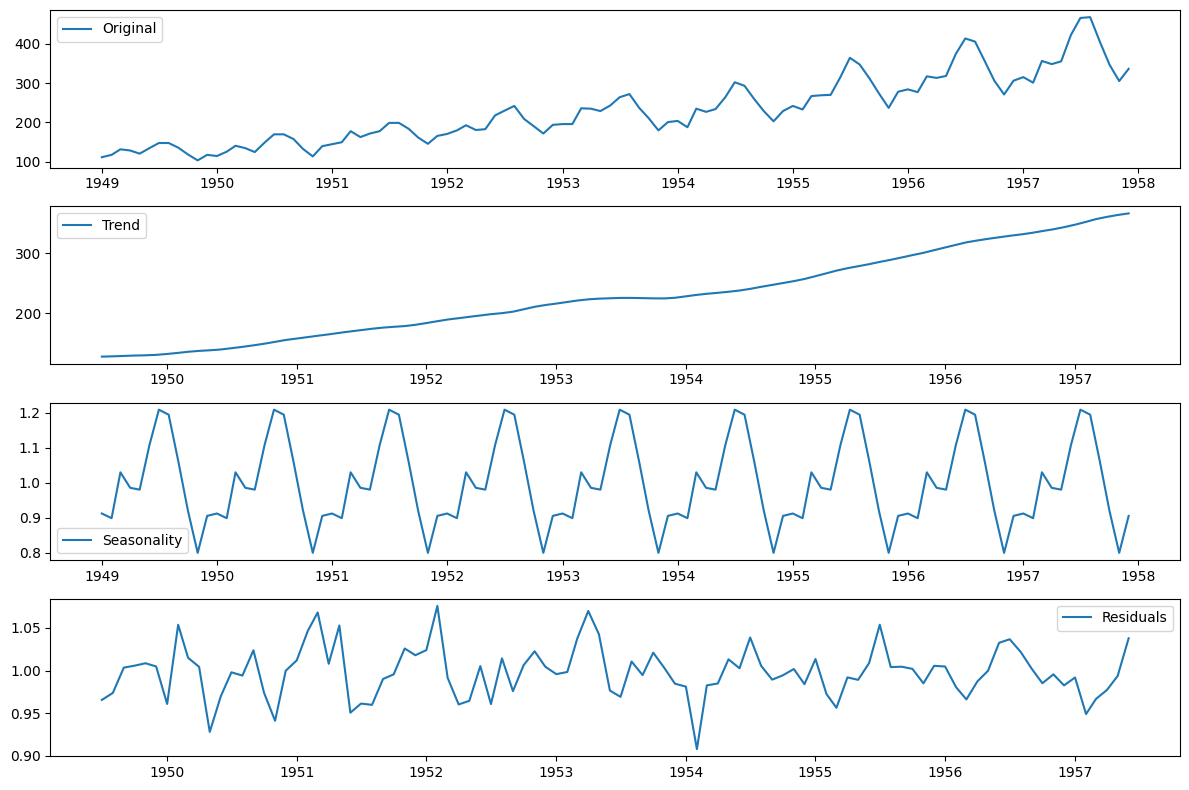

In [8]:
# Task Five

result = seasonal_decompose(df, model='multiplicative')

plt.figure(figsize=(12,8))
plt.subplot(411)
plt.plot(df, label='Original')
plt.legend(loc='best')
plt.subplot(412)
plt.plot(result.trend, label='Trend')
plt.legend(loc='best')
plt.subplot(413)
plt.plot(result.seasonal, label='Seasonality')
plt.legend(loc='best')
plt.subplot(414)
plt.plot(result.resid, label='Residuals')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

The decomposition plots break down the time series into three core components. We can see that the multiplicative model was the right choice bacause the Trend graph isolates the continuous growth in passenger numbers from 1949 to 1957 and avoids the yearly fluctuations. The Seasonality plot shows a repeating 12-month pattern meaning that the high and low travel seasons happen at the exact same times every year (which is pretty logic after all). Finally, the Residuals are centered around 1 and look more or less random, which means the model effectively captured the main structure of the data and left only the unpredictable variations behind.